In [1]:
import argparse
import pathlib
from pathlib import Path
import time
from datetime import timedelta
import json
import os
import pandas as pd
import numpy as np
import itertools
import csv
import anndata
import javabridge
import tensorflow as tf
import pathml
from pathml.core import CODEXSlide
from pathml.core import SlideData
from scipy.spatial.distance import cdist
from pathml.preprocessing import Pipeline, CollapseRunsCODEX, SegmentMIF, QuantifyMIF

2023-02-23 01:40:54.865443: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2023-02-23 01:40:54.865486: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
print(f"working dir: {os.getcwd()}")

working dir: /n/data2/dfci/cancerimm/wucherpfennig/bhawesh


In [3]:
# Data Directory

os.chdir("/n/data2/dfci/cancerimm/wucherpfennig/bhawesh/projects/CODEX/test_p02")

In [4]:
metadata_p = Path("experiment_edited.json")

In [5]:
! ls

experiment_edited.json
p02_bl_cropped_20220516_Exp030_P02_BL_anndata.h5ad
p02_bl_cropped_20220516_Exp030_P02_BL_anndata.h5seurat
p02_bl_cropped_20220516_Exp030_P02_BL.h5path
p02_bl_cropped_20220516_Exp030_P02_BL_h5path_channel_order.txt
stitched.pattern
symlink
symlink_edited


In [6]:
with open(metadata_p) as f:
            experiment_metadata = json.load(f)
            channel_names = experiment_metadata["channelNames"]["channelNamesArray"]
            experiment_name = experiment_metadata["name"]

In [7]:
newlist = []
for i, v in enumerate(channel_names):
    totalcount = channel_names.count(v)
    count = channel_names[:i].count(v)
    newlist.append(v + "-" + str(count + 1) if totalcount > 1 else v)
channel_names = newlist

In [8]:
wsi_path = 'p02_bl_cropped_20220516_Exp030_P02_BL.h5path'
channels_path =  'p02_bl_cropped_20220516_Exp030_P02_BL_h5path_channel_order.txt'

In [9]:
wsi = SlideData(str(wsi_path))

/n/data2/dfci/cancerimm/wucherpfennig/tools/conda_codex_lab/lib/python3.8/site-packages/anndata/_io/h5ad.py:64: FutureWarning: The `force_dense` argument is deprecated. Use `as_dense` instead.
  warn(


In [10]:
channels = pd.read_csv(channels_path, sep = "\t", header = None)
channel_names = list(channels[1].values)

print("loaded channels:", channel_names, "\n")

loaded channels: ['Blank-1', 'Blank-2', 'Blank-3', 'Clec2d', 'PD-L1', 'CD45-RO', 'N-Cadherin', 'TCF7', 'CD3e', 'CD163', 'CD103', 'CXCR5', 'FAP', 'E-Cadherin', 'cl-Caspase3', 'PD-1', 'GZMB-D6E9W', 'CD1c', 'DAPI-09', 'CXCL13', 'CA9', 'FOXP3', 'CD56', 'CD31', 'GZMK', 'SLUG', 'Podoplanin', 'CD66b', 'Ki67', 'CD4', 'MHC1', 'CD25', 'DC-LAMP', 'Pancytokeratin', 'CD8', 'CD68', 'CD20', 'HLA-DR', 'Vimentin', 'Blank-4', 'Blank-5', 'Blank-6'] 



In [11]:
# 'CD3e', 'CD4', 'CD8', 'CD68', 'CD20', 'CD31', 'Pancytokeratin'

In [12]:
wsi.tiles.keys

['(0, 0)',
 '(0, 1848)',
 '(0, 3696)',
 '(1848, 0)',
 '(1848, 1848)',
 '(1848, 3696)',
 '(3696, 0)',
 '(3696, 1848)',
 '(3696, 3696)']

In [13]:
tile = wsi.tiles[(1848, 1848)]
tile.masks.keys()

dict_keys(['cell_segmentation', 'nuclear_segmentation'])

In [14]:
mask = tile.masks["nuclear_segmentation"].astype(np.int).squeeze()

In [15]:
mask.shape, len(np.unique(mask))

((2048, 2048), 2383)

In [16]:
# Convert to float and remove nans due to overflow by the max of the array
# If na
tile.image = tile.image.astype(np.float64)
global_max = np.nanmax(tile.image[tile.image != np.inf])
print(global_max)
tile.image[tile.image>global_max] = global_max

65504.0


In [17]:
# path = Path("P02_BL_cropped.ome.tiff")
# slide = CODEXSlide(str(path))
# print(f"loaded image of shape {slide.slide.shape_list[0]}")

In [18]:
# Raise assertion error if there are nans in the image
assert not np.isnan(tile.image).any(), "There are NaN values in the array"
assert not np.isinf(tile.image).any(), "Array contains infinite value(s)."


In [19]:
os.chdir("/n/data2/dfci/cancerimm/wucherpfennig/bhawesh/code")

In [20]:
import cvmask, transforms_cell_seg

In [21]:
from transforms import FilterEdgeCells, MembraneMarkerWatershed, REDSEAQuantifyMIF, CheckNACounts
from transforms_cell_seg import CellSegQuantifyMIF
# from scipy.spatial.distance import cdist

In [22]:
nucleus_marker_index = channel_names.index("DAPI-09")
cytoplasm_marker_index = channel_names.index("MHC1")

print(f"Using nucleus marker: {channel_names[nucleus_marker_index]}\tPathml index: {nucleus_marker_index}")
print(f"Using cytoplasm marker: {channel_names[cytoplasm_marker_index]}\tPathml index: {cytoplasm_marker_index}")


Using nucleus marker: DAPI-09	Pathml index: 18
Using cytoplasm marker: MHC1	Pathml index: 30


In [30]:
# tile_overlap = 200
# segmentation_mask = 'nuclear_segmentation'

# pipe = Pipeline([
#         CollapseRunsCODEX(z = 0),
#         SegmentMIF(
#             model = 'mesmer',
#             nuclear_channel = nucleus_marker_index,
#             cytoplasm_channel = cytoplasm_marker_index,
#             image_resolution = 0.5),
#         #MembraneMarkerWatershed(
#         #    membrane_channel = cytoplasm_marker_index,
#         #    marker_segmentation_mask = "nuclear_segmentation",
#         #    watershed_line = False,
#         #    mask_name = "watershed"),
#         CellSegQuantifyMIF(segmentation_mask = segmentation_mask),
#         FilterEdgeCells(edge_distance = tile_overlap / 2, slide_shape = slide.shape)
#     ])

In [32]:
import matplotlib.pyplot as plt

In [23]:
mask_reindexed, mask_counts = CellSegQuantifyMIF.split_cells(mask.copy())

In [24]:
mask_counts, len(np.unique(mask_reindexed))

(2706, 2707)

In [25]:
mask_dil = CellSegQuantifyMIF.grow_masks(mask_reindexed, 3, method = 'Standard', num_neighbors = 30)
print(len(np.unique(mask_reindexed)), len(np.unique(mask_dil)))
comp_mean_3, mean_3, areas_3 = CellSegQuantifyMIF.convert_seg_to_CVMask(mask_dil, tile.image)

Standard growth selected


In [28]:
abs(comp_mean_3-mean_3).mean(), (comp_mean_3-mean_3).max(), (comp_mean_3-mean_3).min()

(117.01860882643638, 811.8763301773142, -25744.71165076183)

In [29]:
comp_mean_3.shape

(2706, 42)

In [30]:
CD_20_comp_3 = comp_mean_3[:, channel_names.index('CD20')]
CD_20_mean_3 = mean_3[:, channel_names.index('CD20')]
CD_68_comp_3 = comp_mean_3[:, channel_names.index('CD68')]
CD_68_mean_3 = mean_3[:, channel_names.index('CD68')]

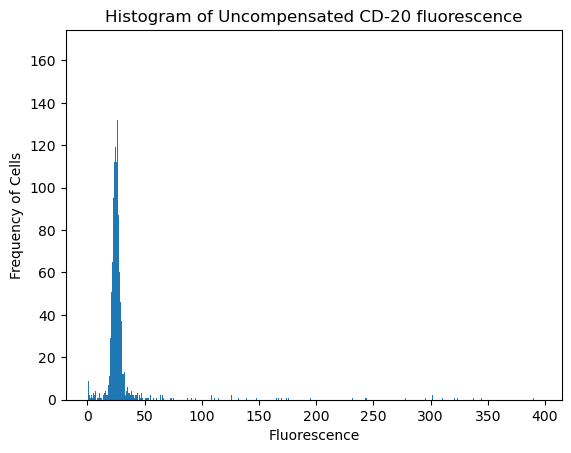

In [33]:
p = plt.hist((CD_20_mean_3[CD_20_mean_3<400]+1), bins=1000)
plt.title("Histogram of Uncompensated CD-20 fluorescence")
plt.xlabel("Fluorescence")
plt.ylabel("Frequency of Cells")
plt.show()

In [34]:
CD_20_pos_cells_uncomp = (CD_20_mean_3>50)
CD_20_pos_cells_uncomp.sum(), len(CD_20_pos_cells_uncomp)

(184, 2706)

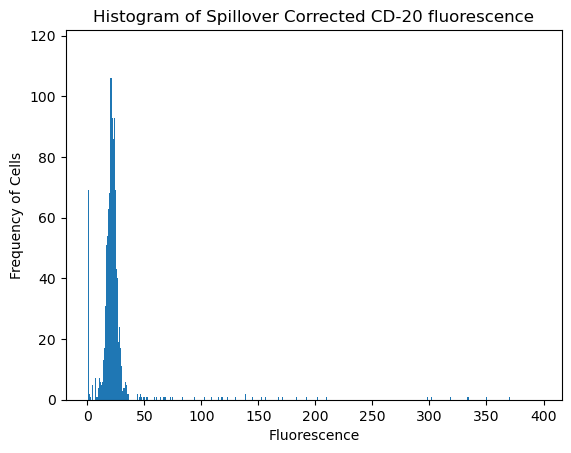

In [35]:
p = plt.hist((CD_20_comp_3[CD_20_comp_3<400]+1), bins=1000)
plt.title("Histogram of Spillover Corrected CD-20 fluorescence")
plt.xlabel("Fluorescence")
plt.ylabel("Frequency of Cells")
plt.show()

In [36]:
CD_20_pos_cells_comp = (CD_20_comp_3>50)
CD_20_pos_cells_comp.sum(), len(CD_20_pos_cells_comp)

(153, 2706)

In [37]:
from scipy.stats import percentileofscore
percentileofscore(CD_20_comp_3, 50), percentileofscore(CD_20_mean_3, 50)

(94.34589800443459, 93.20029563932003)

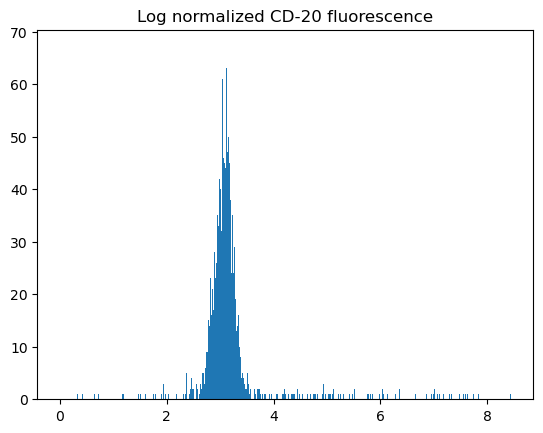

In [38]:
p = plt.hist(np.log(CD_20_comp_3+1), bins=1000)
plt.title("Log normalized CD-20 fluorescence")
plt.show()

In [39]:
percentileofscore(np.log(CD_20_comp_3+1), 3.7)

93.53288987435329

In [40]:
cut_off = 94
CD_20_cutoff = np.percentile(CD_20_comp_3, cut_off)
CD_20_cutoff = 50

In [41]:
np.percentile(CD_20_comp_3, 99)

1054.8169474943609

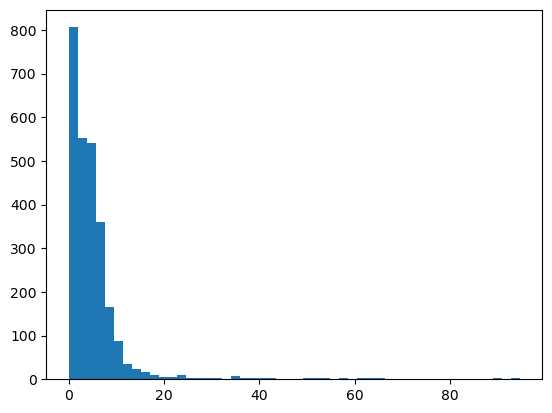

In [42]:
p = plt.hist(abs(CD_20_comp_3-CD_20_mean_3)[abs(CD_20_comp_3-CD_20_mean_3)<100], bins=50)
plt.show()

In [43]:
cut_off_diff = 96
CD_20_diff_cutoff = np.percentile(abs(CD_20_comp_3-CD_20_mean_3), cut_off_diff)
CD_20_diff_cutoff

19.059061858210736

In [44]:
percentileofscore(abs(CD_20_comp_3-CD_20_mean_3), 20)

96.11973392461198

In [45]:
np.sum(np.logical_and(~CD_20_pos_cells_comp, ~CD_20_pos_cells_uncomp))

2521

In [46]:
def get_closest_median(arr):
    median = np.median(arr)
    closest = arr[np.abs(arr - median).argmin()]
    return closest

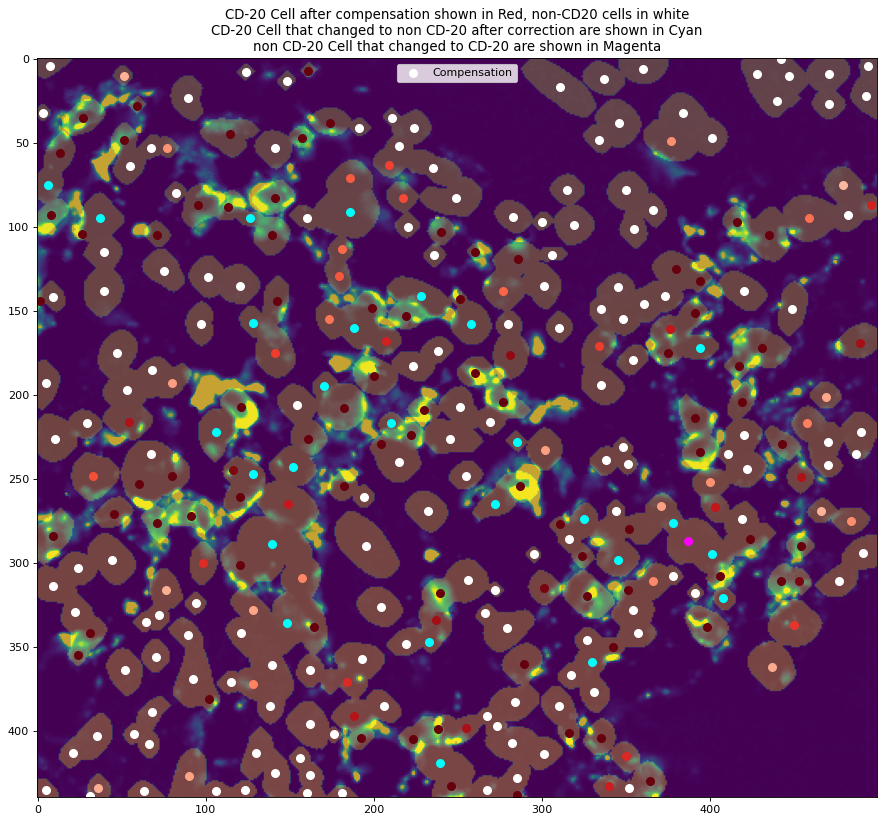

In [47]:
from matplotlib.pyplot import figure
idx1, idx2, idx3, idx4 = 1600, 2040, 0, 500
figure(figsize=(16, 12), dpi=80)
CD_pos_neg = 0
CD_neg_pos = 0
CD_pos = 0
CD_neg = 0
for label in np.unique(mask_dil[idx1:idx2, idx3:idx4]):
    if label!=0:
        rows, columns = np.where(mask_dil[idx1:idx2, idx3:idx4] ==label)
        r_, c_ =  get_closest_median(rows), get_closest_median(columns)
        is_CD_20 = CD_20_pos_cells_comp[label-1]
        was_CD_20 = CD_20_pos_cells_uncomp[label-1]
        value = CD_20_mean_3[label-1]
        comp_value = CD_20_comp_3[label-1]
        
        if was_CD_20 and not is_CD_20:
            plt.scatter(c_,r_, color='cyan', s = 50, )
            CD_pos_neg+=1
            CD_neg+=1
        
        elif not was_CD_20 and not is_CD_20:
            plt.scatter(c_,r_, color='white', s = 50,)
            CD_neg+=1
        
        elif not was_CD_20 and is_CD_20:
            plt.scatter(c_,r_, color='magenta', s = 50,)
            CD_neg_pos+=1
            CD_pos+=1
        else:
            plt.scatter(c_,r_, c= comp_value, vmin = 0, vmax =np.percentile(CD_20_comp_3, 97),
                          s = 50, cmap='Reds', )
            CD_pos+=1
plt.imshow(tile.image[idx1:idx2, idx3:idx4, channel_names.index('CD20')], vmax=3000)
plt.imshow(mask_dil[idx1:idx2, idx3:idx4],alpha=0.3)

plt.title("CD-20 Cell after compensation shown in Red, non-CD20 cells in white\n" + 
                "CD-20 Cell that changed to non CD-20 after correction are shown in Cyan\n"+
         "non CD-20 Cell that changed to CD-20 are shown in Magenta")
plt.legend(['Compensation'], markerscale=1, loc = "upper center")

plt.show()

In [48]:
CD_pos_neg, CD_neg_pos, CD_pos, CD_neg, len(np.unique(mask_dil[idx1:idx2, idx3:idx4]))-1

(26, 1, 131, 179, 310)

In [49]:
CD_68_pos_cells_uncomp = (CD_68_mean_3>500)
CD_68_pos_cells_uncomp.sum(), len(CD_68_pos_cells_uncomp)

(306, 2706)

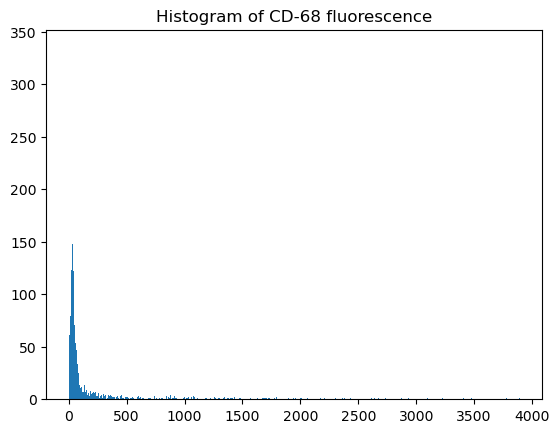

In [50]:
p = plt.hist((CD_68_comp_3[CD_68_comp_3<4000]+1), bins=1000)
plt.title("Histogram of CD-68 fluorescence")
plt.show()

In [51]:
CD_68_pos_cells_comp = (CD_68_comp_3>500)
CD_68_pos_cells_comp.sum(), len(CD_68_pos_cells_comp)

(269, 2706)

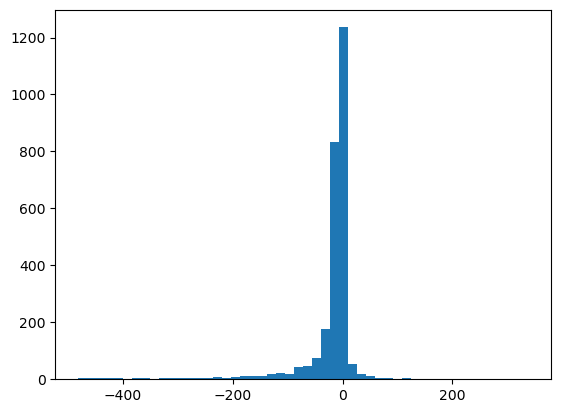

In [52]:
p = plt.hist((CD_68_comp_3-CD_68_mean_3)[abs(CD_68_comp_3-CD_68_mean_3)<500], bins=50)
plt.show()

In [53]:
cut_off_diff = 90
CD_68_diff_cutoff = np.percentile(abs(CD_68_comp_3-CD_68_mean_3), cut_off_diff)
CD_68_diff_cutoff

63.875152653783005

In [54]:
percentileofscore(CD_68_comp_3, 500), percentileofscore(CD_68_mean_3, 500)

(90.05912786400592, 88.69179600886918)

In [55]:
percentileofscore(CD_20_mean_3, 258)

96.8218773096822

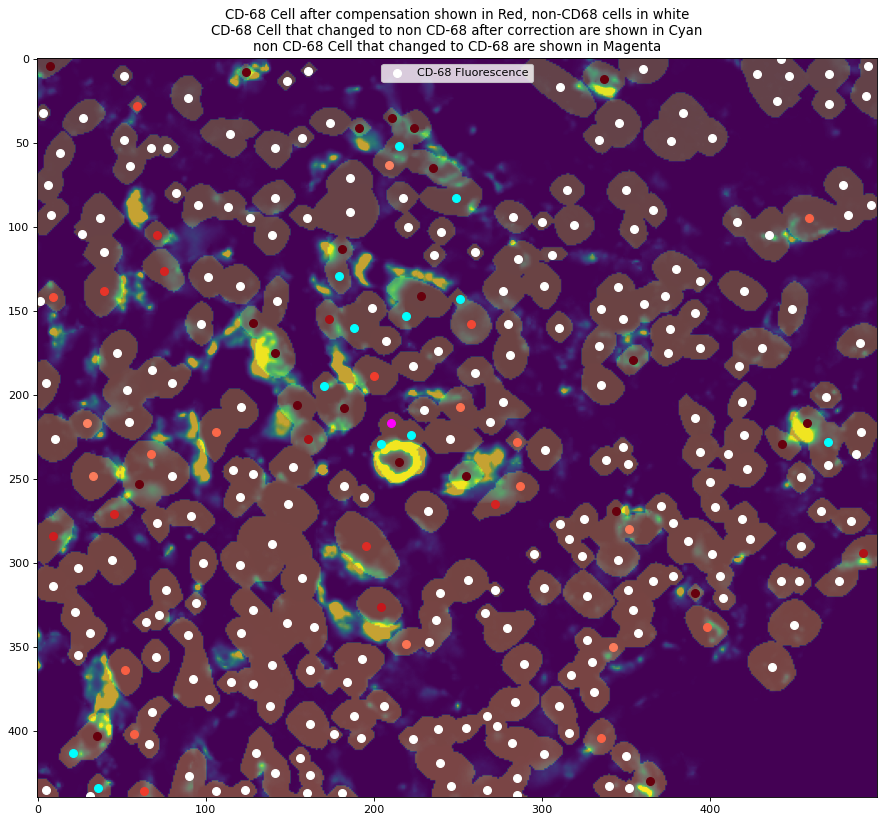

In [56]:
from matplotlib.pyplot import figure
idx1, idx2, idx3, idx4 = 1600, 2040, 0, 500
figure(figsize=(16, 12), dpi=80)
CD_pos_neg = 0
CD_neg_pos = 0
CD_pos = 0
CD_neg = 0
for label in np.unique(mask_dil[idx1:idx2, idx3:idx4]):
    if label!=0:
        rows, columns = np.where(mask_dil[idx1:idx2, idx3:idx4] ==label)
        r_, c_ =  get_closest_median(rows), get_closest_median(columns)
        is_CD_68 = CD_68_pos_cells_comp[label-1]
        was_CD_68 = CD_68_pos_cells_uncomp[label-1]
        value = CD_68_mean_3[label-1]
        comp_value = CD_68_comp_3[label-1]
        
        if was_CD_68 and not is_CD_68:
            plt.scatter(c_,r_, color='cyan', s = 50, )
            CD_pos_neg+=1
            CD_neg+=1
        
        elif not was_CD_68 and not is_CD_68:
            plt.scatter(c_,r_, color='white', s = 50,)
            CD_neg+=1
        
        elif not was_CD_68 and is_CD_68:
            plt.scatter(c_,r_, color='magenta', s = 50,)
            CD_neg_pos+=1
            CD_pos+=1
        else:
            plt.scatter(c_,r_, c= comp_value, vmin = 0, vmax =np.percentile(CD_68_comp_3, 95),
                          s = 50, cmap='Reds', )
            CD_pos+=1
plt.imshow(tile.image[idx1:idx2, idx3:idx4, channel_names.index('CD68')], vmax=10000)
plt.imshow(mask_dil[idx1:idx2, idx3:idx4],alpha=0.3)

plt.title("CD-68 Cell after compensation shown in Red, non-CD68 cells in white\n" + 
                "CD-68 Cell that changed to non CD-68 after correction are shown in Cyan\n"+
         "non CD-68 Cell that changed to CD-68 are shown in Magenta")
plt.legend(['CD-68 Fluorescence'], markerscale=1, loc = "upper center")

plt.show()

In [57]:
CD_pos_neg, CD_neg_pos, CD_pos, CD_neg

(12, 1, 56, 254)

In [58]:
mask_dil = CellSegQuantifyMIF.grow_masks(mask_reindexed, 3, method = 'Sequential')
print(len(np.unique(mask_reindexed)), len(np.unique(mask_dil)))
comp_mean_3, mean_3, areas_3 = CellSegQuantifyMIF.convert_seg_to_CVMask(mask_dil, tile.image)

Sequential growth selected
2707 2707


In [60]:
abs(comp_mean_3-mean_3).mean(), (comp_mean_3-mean_3).max(), (comp_mean_3-mean_3).min()

(109.04513912117882, 417.1300021179886, -23487.140456458455)

In [61]:
CD_20_comp_3 = comp_mean_3[:, channel_names.index('CD20')]
CD_20_mean_3 = mean_3[:, channel_names.index('CD20')]
CD_68_comp_3 = comp_mean_3[:, channel_names.index('CD68')]
CD_68_mean_3 = mean_3[:, channel_names.index('CD68')]

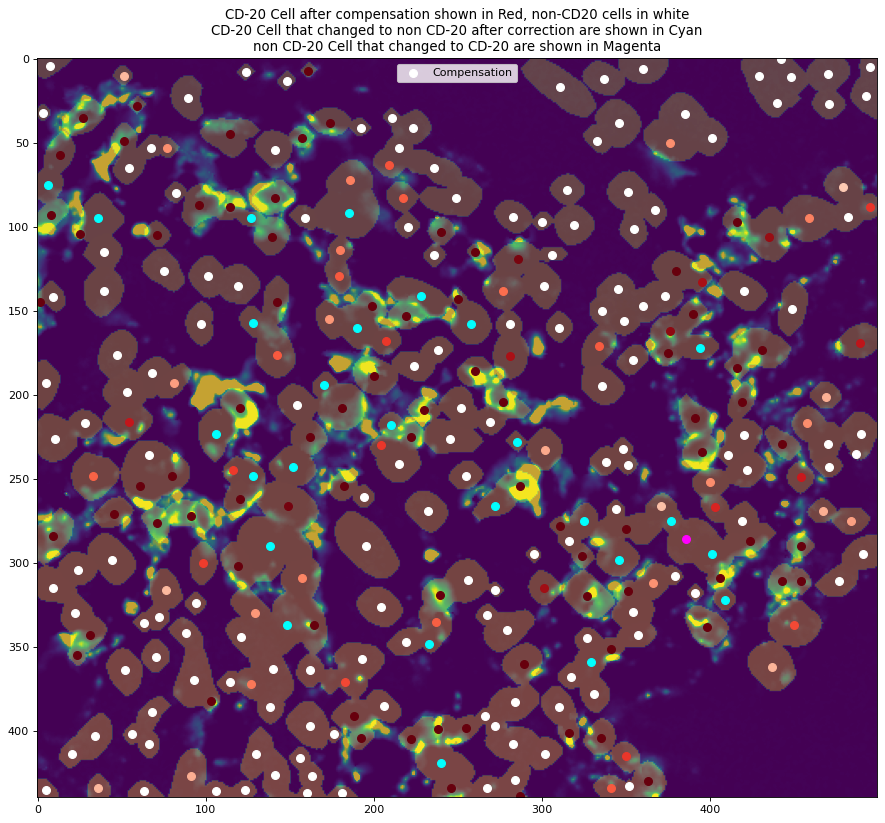

In [62]:
from matplotlib.pyplot import figure
idx1, idx2, idx3, idx4 = 1600, 2040, 0, 500
figure(figsize=(16, 12), dpi=80)
CD_pos_neg = 0
CD_neg_pos = 0
CD_pos = 0
CD_neg = 0
for label in np.unique(mask_dil[idx1:idx2, idx3:idx4]):
    if label!=0:
        rows, columns = np.where(mask_dil[idx1:idx2, idx3:idx4] ==label)
        r_, c_ =  get_closest_median(rows), get_closest_median(columns)
        is_CD_20 = CD_20_pos_cells_comp[label-1]
        was_CD_20 = CD_20_pos_cells_uncomp[label-1]
        value = CD_20_mean_3[label-1]
        comp_value = CD_20_comp_3[label-1]
        
        if was_CD_20 and not is_CD_20:
            plt.scatter(c_,r_, color='cyan', s = 50, )
            CD_pos_neg+=1
            CD_neg+=1
        
        elif not was_CD_20 and not is_CD_20:
            plt.scatter(c_,r_, color='white', s = 50,)
            CD_neg+=1
        
        elif not was_CD_20 and is_CD_20:
            plt.scatter(c_,r_, color='magenta', s = 50,)
            CD_neg_pos+=1
            CD_pos+=1
        else:
            plt.scatter(c_,r_, c= comp_value, vmin = 0, vmax =np.percentile(CD_20_comp_3, 97),
                          s = 50, cmap='Reds', )
            CD_pos+=1
plt.imshow(tile.image[idx1:idx2, idx3:idx4, channel_names.index('CD20')], vmax=3000)
plt.imshow(mask_dil[idx1:idx2, idx3:idx4],alpha=0.3)

plt.title("CD-20 Cell after compensation shown in Red, non-CD20 cells in white\n" + 
                "CD-20 Cell that changed to non CD-20 after correction are shown in Cyan\n"+
         "non CD-20 Cell that changed to CD-20 are shown in Magenta")
plt.legend(['Compensation'], markerscale=1, loc = "upper center")

plt.show()

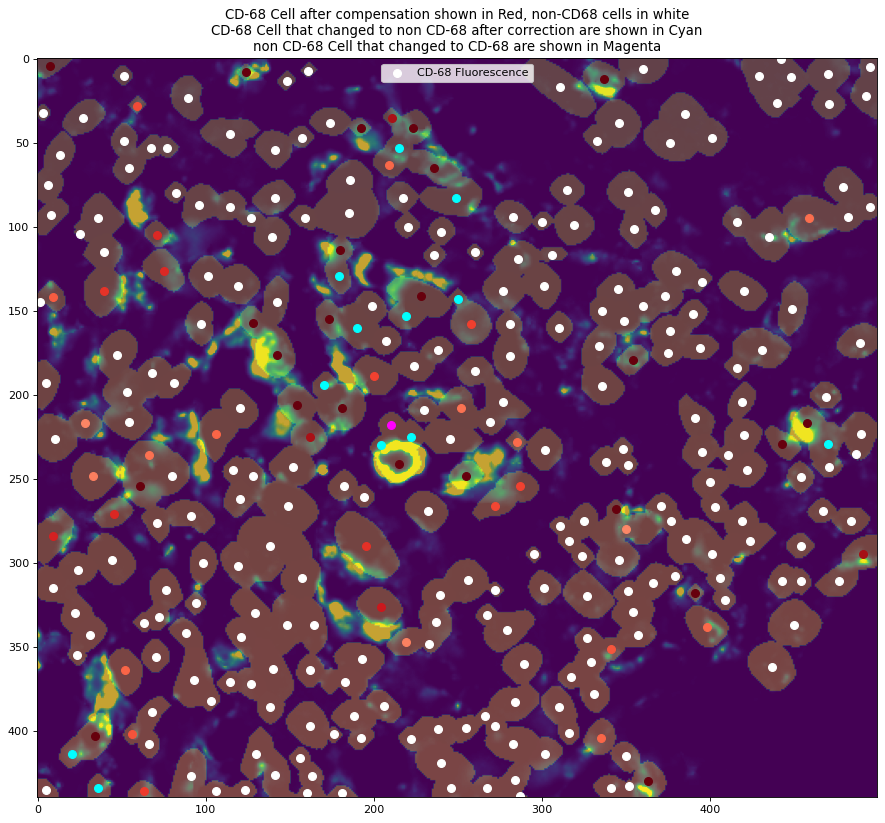

In [63]:
from matplotlib.pyplot import figure
idx1, idx2, idx3, idx4 = 1600, 2040, 0, 500
figure(figsize=(16, 12), dpi=80)
CD_pos_neg = 0
CD_neg_pos = 0
CD_pos = 0
CD_neg = 0
for label in np.unique(mask_dil[idx1:idx2, idx3:idx4]):
    if label!=0:
        rows, columns = np.where(mask_dil[idx1:idx2, idx3:idx4] ==label)
        r_, c_ =  get_closest_median(rows), get_closest_median(columns)
        is_CD_68 = CD_68_pos_cells_comp[label-1]
        was_CD_68 = CD_68_pos_cells_uncomp[label-1]
        value = CD_68_mean_3[label-1]
        comp_value = CD_68_comp_3[label-1]
        
        if was_CD_68 and not is_CD_68:
            plt.scatter(c_,r_, color='cyan', s = 50, )
            CD_pos_neg+=1
            CD_neg+=1
        
        elif not was_CD_68 and not is_CD_68:
            plt.scatter(c_,r_, color='white', s = 50,)
            CD_neg+=1
        
        elif not was_CD_68 and is_CD_68:
            plt.scatter(c_,r_, color='magenta', s = 50,)
            CD_neg_pos+=1
            CD_pos+=1
        else:
            plt.scatter(c_,r_, c= comp_value, vmin = 0, vmax =np.percentile(CD_68_comp_3, 95),
                          s = 50, cmap='Reds', )
            CD_pos+=1
plt.imshow(tile.image[idx1:idx2, idx3:idx4, channel_names.index('CD68')], vmax=10000)
plt.imshow(mask_dil[idx1:idx2, idx3:idx4],alpha=0.3)

plt.title("CD-68 Cell after compensation shown in Red, non-CD68 cells in white\n" + 
                "CD-68 Cell that changed to non CD-68 after correction are shown in Cyan\n"+
         "non CD-68 Cell that changed to CD-68 are shown in Magenta")
plt.legend(['CD-68 Fluorescence'], markerscale=1, loc = "upper center")

plt.show()

In [68]:
import numpy as np

def standardize_and_clip(array, a_min=None, a_max=None):
    # Calculate mean and standard deviation along the channels (axis=2)
    mean = np.mean(array, axis=0)
    std = np.std(array, axis=0)
    
    # Standardize the array along each channel
    standardized = (array - mean) / std
    
    # Clip the standardized array to the specified range
    if a_min is not None and a_max is not None:
        clipped = np.clip(standardized, a_min, a_max)
    
        return clipped
    else:
        return standardized


In [69]:
idx = [channel_names.index('CD3e'), channel_names.index('CD4'), channel_names.index('CD8'), 
       channel_names.index('CD68'), channel_names.index('CD20'), channel_names.index('CD31'),
       channel_names.index('Pancytokeratin')]

counts_ls_umap = comp_mean_3[:, idx]
counts_ls_uncomp_umap = mean_3[:, idx]


In [70]:
counts_ls_umap_std = standardize_and_clip(counts_ls_umap, a_max=6, a_min=-6)
counts_ls_uncomp_umap_std = standardize_and_clip(counts_ls_uncomp_umap, a_max=6, a_min=-6)

In [71]:
import numpy as np
import umap

In [72]:


def create_umap_embeddings(array, n_neighbors=15, min_dist=0.1):
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist)
    embeddings = reducer.fit_transform(array)
    return embeddings
def plot_umap_embeddings(embeddings, s=5):
    
    plt.scatter(embeddings[:, 0], embeddings[:, 1], s=s)
    plt.show()

In [73]:
embeddings_ls = (create_umap_embeddings(counts_ls_umap_std, n_neighbors=15))
embeddings_uncomp = (create_umap_embeddings(counts_ls_uncomp_umap_std, n_neighbors=15))

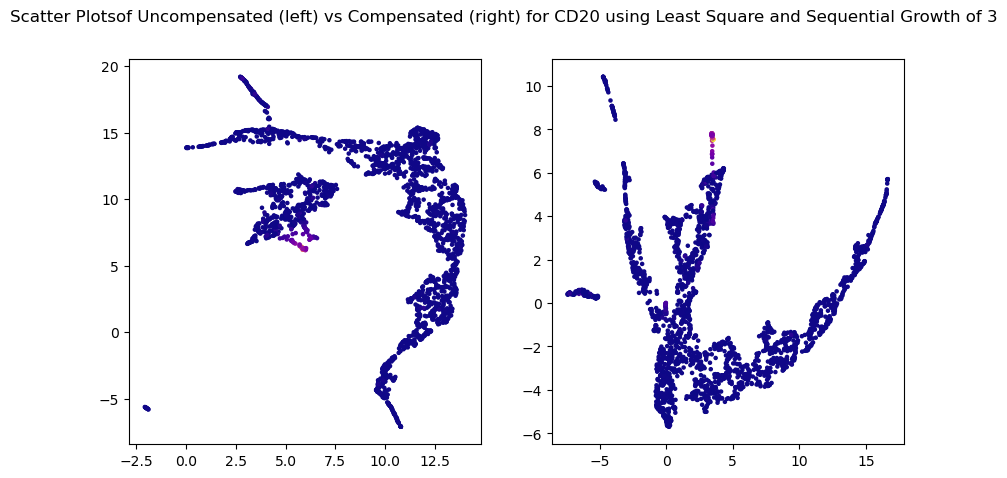

In [77]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].scatter(embeddings_uncomp[:, 0], embeddings_uncomp[:, 1],
               s=5, c=counts_ls_uncomp_umap[:, 4], cmap='plasma')
axs[1].scatter(embeddings_ls[:, 0], embeddings_ls[:, 1], s=5, 
                           c=counts_ls_umap[:, 4], cmap='plasma')
fig.suptitle('Scatter Plotsof Uncompensated (left) vs Compensated (right) for CD20 using Least Square and \
Sequential Growth of 3')
plt.show()